In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('churn_clean.csv')

# Drop unrelated columns
columns_to_drop = ['Customer_id', 'Zip', 'City', 'State', 'County', 'Lat', 'Lng', 'TimeZone', 'Job', 'Marital', 'Gender']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Fill missing values
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())
df['Bandwidth_GB_Year'] = df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].median())

# Convert Churn to binary (Yes = 1, No = 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop duplicate rows
df = df.drop_duplicates()

# Quick check for missing values
print(df.isnull().sum())

CaseOrder                  0
Interaction                0
UID                        0
Population                 0
Area                       0
Children                   0
Age                        0
Income                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport                0
StreamingTV                0
StreamingMovies            0
PaperlessBilling           0
PaymentMethod              0
Tenure                     0
MonthlyCharge              0
Bandwidth_GB_Year          0
Item1                      0
Item2                      0
Item3                      0
Item4         

In [6]:
# Show summary statistics for the relevant variables
print(df[['Churn', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']].describe())

              Churn        Tenure  MonthlyCharge  Bandwidth_GB_Year
count  10000.000000  10000.000000   10000.000000       10000.000000
mean       0.265000     34.526188     172.624816        3392.341550
std        0.441355     26.443063      42.943094        2185.294852
min        0.000000      1.000259      79.978860         155.506715
25%        0.000000      7.917694     139.979239        1236.470827
50%        0.000000     35.430507     167.484700        3279.536903
75%        1.000000     61.479795     200.734725        5586.141370
max        1.000000     71.999280     290.160419        7158.981530


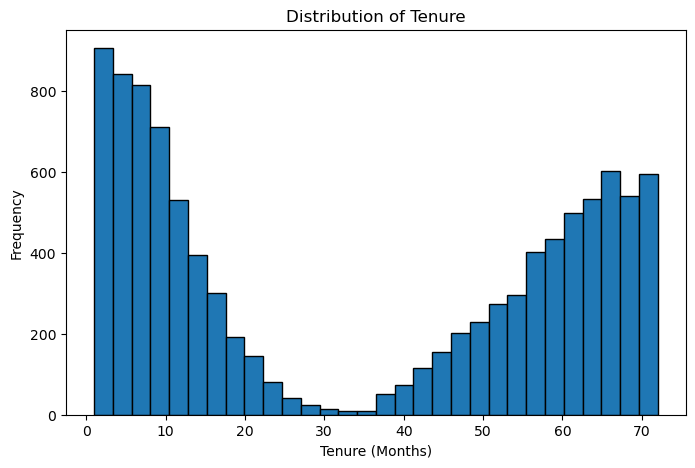

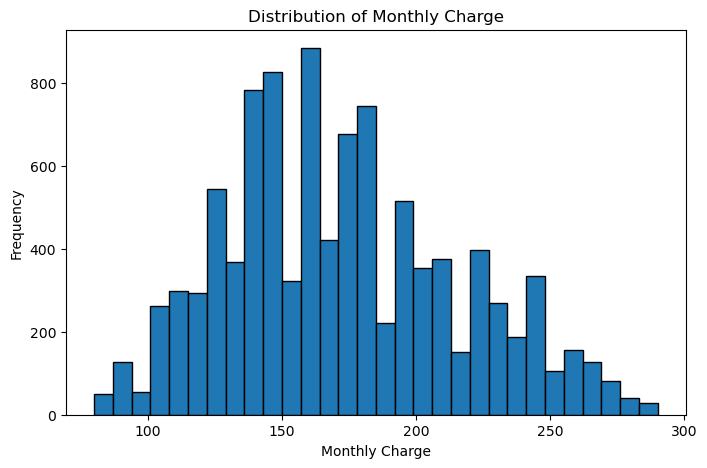

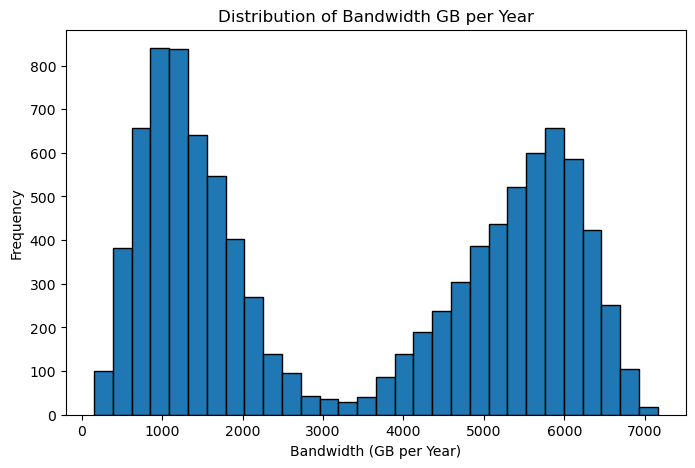

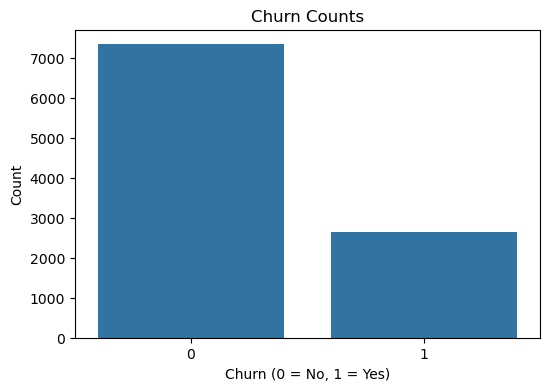

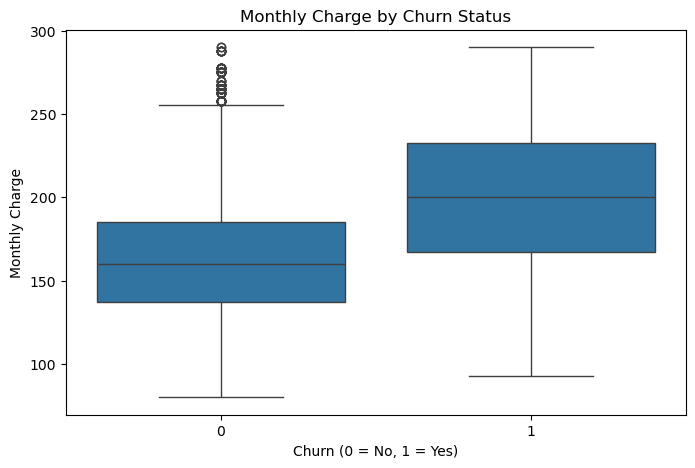

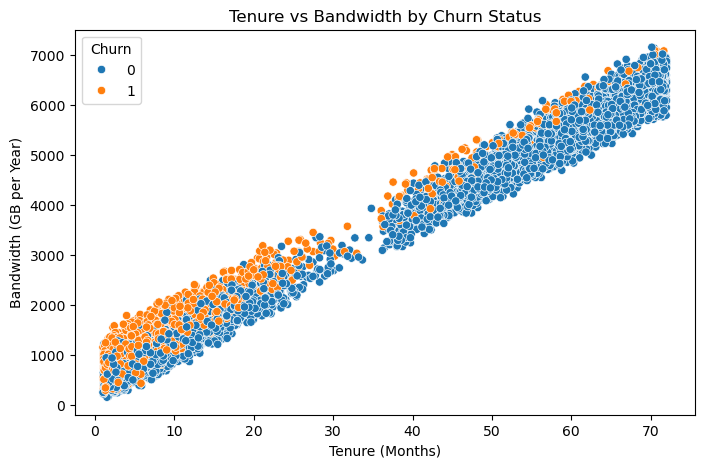

In [8]:
# Univariate - Histograms
plt.figure(figsize=(8, 5))
plt.hist(df['Tenure'], bins=30, edgecolor='black')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['MonthlyCharge'], bins=30, edgecolor='black')
plt.title('Distribution of Monthly Charge')
plt.xlabel('Monthly Charge')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['Bandwidth_GB_Year'], bins=30, edgecolor='black')
plt.title('Distribution of Bandwidth GB per Year')
plt.xlabel('Bandwidth (GB per Year)')
plt.ylabel('Frequency')
plt.show()

# Univariate - Bar plot for Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Counts')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Bivariate - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharge', data=df)
plt.title('Monthly Charge by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charge')
plt.show()

# Bivariate - Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Tenure', y='Bandwidth_GB_Year', hue='Churn', data=df)
plt.title('Tenure vs Bandwidth by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Bandwidth (GB per Year)')
plt.legend(title='Churn')
plt.show()
#(GeeksforGeeks)

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Features to scale
features_to_scale = ['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']

# Apply the scaler
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Confirm scaling by checking means and standard deviations
print(df[features_to_scale].mean())
print(df[features_to_scale].std())

Tenure               2.273737e-17
MonthlyCharge       -1.563194e-17
Bandwidth_GB_Year    4.547474e-17
dtype: float64
Tenure               1.00005
MonthlyCharge        1.00005
Bandwidth_GB_Year    1.00005
dtype: float64


In [14]:
# Save the final prepared dataset
df.to_csv('churn_prepared_for_logistic.csv', index=False)

In [19]:
import statsmodels.api as sm

# Define the independent variables (features) and dependent variable
X = df[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']]  # all 3 predictors you identified
y = df['Churn']  # dependent variable

# Add a constant term for the intercept
X = sm.add_constant(X)

# Build the initial logistic regression model
initial_model = sm.Logit(y, X).fit()

# Show the summary output
print(initial_model.summary())

Optimization terminated successfully.
         Current function value: 0.324272
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Sat, 26 Apr 2025   Pseudo R-squ.:                  0.4392
Time:                        15:26:21   Log-Likelihood:                -3242.7
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0928      0.048    -44.003      0.000      -2.186      -2.000
Tenure  

In [21]:
# Refit the model (same predictors)
X_reduced = df[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']]
X_reduced = sm.add_constant(X_reduced)

reduced_model = sm.Logit(y, X_reduced).fit()

# Show the reduced model summary
print(reduced_model.summary())

Optimization terminated successfully.
         Current function value: 0.324272
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Sat, 26 Apr 2025   Pseudo R-squ.:                  0.4392
Time:                        15:42:37   Log-Likelihood:                -3242.7
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0928      0.048    -44.003      0.000      -2.186      -2.000
Tenure  

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predict probabilities using reduced model
y_pred_prob = reduced_model.predict(X_reduced)

# Convert probabilities to binary (threshold = 0.5)
y_pred = [1 if prob > 0.5 else 0 for prob in y_pred_prob]

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy score
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")

#(Murel)

Confusion Matrix:
[[6783  567]
 [ 985 1665]]
Accuracy: 0.8448
